**Jovita Berzinyte (185905), Violett Korbély (186626), Win Pa Pa Swe (186421)**

In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# **Data Import**

In [ ]:
file_path = "https://raw.githubusercontent.com/JovitaBer/ML_2026_Practice/main/greenhouse-gas-emissions.xlsx"

#load the variable list
df_variable_list = pd.read_excel(file_path, sheet_name='Variable_list')

#load the 'UK_by_source' sheet
df_uk_by_source = pd.read_excel(file_path, sheet_name='UK_by_source')

#load the 'UNFCCC_by_source' sheet
df_unfccc_by_source = pd.read_excel(file_path, sheet_name='UNFCCC_by_source')

In [ ]:
display(df_variable_list)

,Variable,Description,In 'UK_by_source' dataset?,In 'UNFCCC_by_source' dataset?
0,Included in UK territorial total,Identifies emissions included in the UK territ...,Yes,No
1,Included in UK UNFCCC total,Identifies emissions included in the territori...,No,Yes
2,Included in UK Paris Agreement total,Identifies emissions included in the territori...,No,Yes
3,GHG,"The greenhouse gas emitted, with different spe...",Yes,Yes
4,GHG grouped,"The greenhouse gas emitted, with F-gases group...",Yes,Yes
5,CRT category,Categories defined in international guidelines...,Yes,Yes
6,CRT category description,Text description for each CRT category.,Yes,Yes
7,Year,The calendar year in which the emissions occur...,Yes,Yes
8,Territory name,"The territory where the emissions occurred, ei...",Yes,Yes
9,Territorial Emissions Statistics sector,A grouping of the TES subsectors and categories.,Yes,Yes


In [ ]:
df_uk_by_source.head(5)

,Included in UK territorial total,GHG,GHG grouped,CRT category,CRT category description,Year,Territory name,Territorial Emissions Statistics sector,Territorial Emissions Statistics subsector,Territorial Emissions Statistics category,Source,Fuel group,Fuel,Activity,Emissions (MtCO2e)
0,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft - international take off and landing,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.008548
1,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft - international take off and landing,Petroleum,Other petroleum products,Aviation spirit,0.000008
2,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and Bermuda - TOL,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.000012
3,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and CDs - TOL,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.000735
4,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and CDs - TOL,Petroleum,Other petroleum products,Aviation spirit,0.000007


In [ ]:
df_uk_by_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78022 entries, 0 to 78021
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Included in UK territorial total            78022 non-null  object 
 1   GHG                                         78022 non-null  object 
 2   GHG grouped                                 78022 non-null  object 
 3   CRT category                                78022 non-null  object 
 4   CRT category description                    78022 non-null  object 
 5   Year                                        78022 non-null  int64  
 6   Territory name                              78022 non-null  object 
 7   Territorial Emissions Statistics sector     78022 non-null  object 
 8   Territorial Emissions Statistics subsector  78022 non-null  object 
 9   Territorial Emissions Statistics category   78022 non-null  object 
 10  Source    

## **Question 1**
The provided dataset contains UK territorial greenhouse gas emissions by source and activity, cover-
ing the period from 1990 onwards. Emissions are attributed to the sector that emits them directly
and include indicators related to UK territorial totals, international aviation and shipping, and Paris
Agreement coverage.
Perform Exploratory Data Analysis (EDA) to investigate the key factors driving changes in UK
greenhouse gas emissions over time.

**1.1.** Write a Python program to perform a covariance- and correlation-based analysis to examine relationships between emissions, sources, and activities across years. Do not use any built-incovariance or correlation functions. You must implement your calculations.

This is a Pearson correlation coefficient formula:
$$\rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{E[(X-\mu_X)(Y-\mu_Y)]}{\sigma_X \sigma_Y}$$

In [ ]:
df_uk_by_source["Activity"].nunique()

221

In [ ]:
df_uk_by_source["Source"].nunique()

700

In [ ]:
def my_mean(values):
    return sum(values) / len(values)

def my_covariance(x, y):
    """
    Covariance measures how two variables change together.
    Positive → they increase together.
    Negative → one increases while the other decreases.
    """
    n = len(x)
    mean_x = my_mean(x)
    mean_y = my_mean(y)
    total = 0
    for i in range(n):
        total += (x[i] - mean_x) * (y[i] - mean_y)
    return total / (n - 1)

def my_std(values):
    mean_v = my_mean(values)
    variance = sum((v - mean_v) ** 2 for v in values) / (len(values) - 1)
    return variance ** 0.5

def my_correlation(x, y):
    """
    Pearson correlation r — ranges from -1 to +1.
      r =  1  → perfect positive relationship
      r = -1  → perfect negative relationship
      r =  0  → no linear relationship
    """
    std_x = my_std(x)
    std_y = my_std(y)
    if std_x == 0 or std_y == 0:
        return float("nan")
    return my_covariance(x, y) / (std_x * std_y)


In [ ]:
# ------------------------------------------------------------
# Total emissions per year
# ------------------------------------------------------------
yearly = (
    df_uk_by_source.groupby("Year")["Emissions (MtCO2e)"]
    .sum()
    .reset_index()
    .sort_values("Year")
)
yearly.columns = ["Year", "Total_Emissions"]

years  = list(yearly["Year"])
totals = list(yearly["Total_Emissions"])

print("\n" + "=" * 55)
print("Overall Trend: Year vs Total Emissions")
print("=" * 55)

cov = my_covariance(years, totals)
cor = my_correlation(years, totals)

print(f"Covariance  = {cov:.2f}")
print(f"Correlation = {cor:.4f}")

if cor < -0.7:
    print("→ Strong NEGATIVE trend: emissions have been falling over time.")
elif cor > 0.7:
    print("→ Strong POSITIVE trend: emissions have been rising over time.")
else:
    print("→ No strong linear trend detected.")


Overall Trend: Year vs Total Emissions
Covariance  = -1304.74
Correlation = -0.9647
→ Strong NEGATIVE trend: emissions have been falling over time.


In [ ]:
# ------------------------------------------------------------
# Emissions by Source
# ------------------------------------------------------------
source_col = "Source"
source_year = (
    df_uk_by_source.groupby(["Year", source_col])["Emissions (MtCO2e)"]
    .sum()
    .unstack(source_col)
    .fillna(0)
)

print("\n" + "=" * 55)
print("How Emmisions of Each Source Correlates with Year")
print("=" * 55)
print(f"{'source':<45} {'r':>7}")
print("-" * 55)

source_correlations = {}
for source in source_year.columns:
    r = my_correlation(list(source_year.index), list(source_year[source]))
    source_correlations[source] = r
    trend = "↓ decreasing" if r < -0.5 else ("↑ increasing" if r > 0.5 else "~ flat")
    print(f"{source:<45} {r:>7.4f}  {trend}")


How Emmisions of Each Source Correlates with Year
source                                              r
-------------------------------------------------------
Abandoned oil wells (offshore)                 0.9928  ↑ increasing
Abandoned oil wells (onshore)                  0.9671  ↑ increasing
Accidental fires - dwellings                  -0.9539  ↓ decreasing
Accidental fires - other buildings            -0.9429  ↓ decreasing
Accidental fires - vehicles                   -0.8961  ↓ decreasing
Adipic acid production                        -0.7881  ↓ decreasing
Aerosols other than metered dose inhalers     -0.0963  ~ flat
Agricultural Horses - Direct                  -0.0509  ~ flat
Agricultural Horses - Indirect Deposition     -0.0509  ~ flat
Agricultural Horses - Indirect Leach          -0.0509  ~ flat
Agricultural engines                          -0.8733  ↓ decreasing
Agriculture - stationary combustion           -0.7049  ↓ decreasing
Airborne Warning And Control Systems          -

In [ ]:
activity_year = (
    df_uk_by_source.groupby(["Year", "Activity"])["Emissions (MtCO2e)"]
    .sum()
    .unstack("Activity")
    .fillna(0)
)

print("\n" + "=" * 55)
print("How Each Activity Type Correlates with Emmisions over Year")
print("=" * 55)
print(f"{'activity type':<30} {'r':>7}")
print("-" * 45)

for activity in activity_year.columns:
    r = my_correlation(list(activity_year.index), list(activity_year[activity]))
    trend = "↓ decreasing" if r < -0.5 else ("↑ increasing" if r > 0.5 else "~ flat")
    print(f"{activity:<30} {r:>7.4f}  {trend}")


How Each Activity Type Correlates with Emmisions over Year
activity type                        r
---------------------------------------------
Acid production                -0.9246  ↓ decreasing
Acrylonitrile                  -0.7611  ↓ decreasing
Active Aircraft                -0.4640  ~ flat
Adipic acid produced           -0.7881  ↓ decreasing
Agricultural Horses            -0.0509  ~ flat
Ammonium Nitrate Application   -0.8952  ↓ decreasing
Ammonium Nitrate Residue       -0.3350  ~ flat
Ammonium Sulphate and Diammonium Phosphate Application  0.6967  ↑ increasing
Ammonium Sulphate and Diammonium Phosphate Residue  0.7978  ↑ increasing
Animal Biomass                  0.8612  ↑ increasing
Anthracite                     -0.8773  ↓ decreasing
Aviation spirit                -0.5870  ↓ decreasing
Aviation turbine fuel           0.4284  ~ flat
Barley residue                 -0.4821  ~ flat
Bio-MTBE                        0.1649  ~ flat
Biodiesel                       0.8764  ↑ increasing

In [ ]:
# ------------------------------------------------------------
# Correlation of each source with TOTAL emissions
# ------------------------------------------------------------

"""
Question: When total UK emissions go up or down, does the source move with them? - is the source a key driver in emissions”

"""

df_filtered = df_uk_by_source[
    df_uk_by_source["Included in UK territorial total"] == "Yes"
]

total_per_year = (
    df_filtered
    .groupby("Year")["Emissions (MtCO2e)"]
    .sum()
    .sort_index()
)

source_year = (
    df_filtered
    .groupby(["Year", "Source"])["Emissions (MtCO2e)"]
    .sum()
    .unstack("Source")
    .fillna(0)
    .sort_index()
)

print("\n" + "=" * 60)
print("Correlation of Each Source with TOTAL Emissions")
print("=" * 60)

for source in source_year.columns:
    r_total = my_correlation(
        list(total_per_year),
        list(source_year[source])
    )

    strength = (
        "Strong driver" if abs(r_total) > 0.8
        else "Moderate driver" if abs(r_total) > 0.5
        else "Weak driver")

    print(f"{source:<45} {r_total:>7.4f}  {strength}")


Correlation of Each Source with TOTAL Emissions
Abandoned oil wells (offshore)                -0.9530  Strong driver
Abandoned oil wells (onshore)                 -0.9002  Strong driver
Accidental fires - dwellings                   0.9490  Strong driver
Accidental fires - other buildings             0.9291  Strong driver
Accidental fires - vehicles                    0.9018  Strong driver
Adipic acid production                         0.6733  Moderate driver
Aerosols other than metered dose inhalers      0.2855  Weak driver
Agricultural Horses - Direct                   0.2405  Weak driver
Agricultural Horses - Indirect Deposition      0.2405  Weak driver
Agricultural Horses - Indirect Leach           0.2405  Weak driver
Agricultural engines                           0.7869  Moderate driver
Agriculture - stationary combustion            0.7975  Moderate driver
Airborne Warning And Control Systems           0.5735  Moderate driver
Aircraft -  military                           0.9216 

In [ ]:
print("\n" + "=" * 55)
print("How Each Activity Correlates with TOTAL Emissions")
print("=" * 55)
print(f"{'activity type':<30} {'r':>7}")
print("-" * 45)

for activity in activity_year.columns:
    r_total = my_correlation(list(total_per_year),list(activity_year[activity]))
    strength = ("Strong driver" if abs(r_total) > 0.8
    else "Moderate driver" if abs(r_total) > 0.5
    else "Weak driver")
    print(f"{activity:<30} {r_total:>10.4f}  {strength}")


How Each Activity Correlates with TOTAL Emissions
activity type                        r
---------------------------------------------
Acid production                    0.8924  Strong driver
Acrylonitrile                      0.6461  Moderate driver
Active Aircraft                    0.5735  Moderate driver
Adipic acid produced               0.6733  Moderate driver
Agricultural Horses                0.2405  Weak driver
Ammonium Nitrate Application       0.8452  Strong driver
Ammonium Nitrate Residue           0.4026  Weak driver
Ammonium Sulphate and Diammonium Phosphate Application    -0.6741  Moderate driver
Ammonium Sulphate and Diammonium Phosphate Residue    -0.7742  Moderate driver
Animal Biomass                    -0.7627  Moderate driver
Anthracite                         0.7789  Moderate driver
Aviation spirit                    0.6829  Moderate driver
Aviation turbine fuel             -0.2779  Weak driver
Barley residue                     0.3951  Weak driver
Bio-MTBE      

**1.2.** Write another Python program to visualise your findings from the previous step and briefly
explain the observed emission patterns. Hints: You may consider using histograms, boxplots,
and scatterplots.

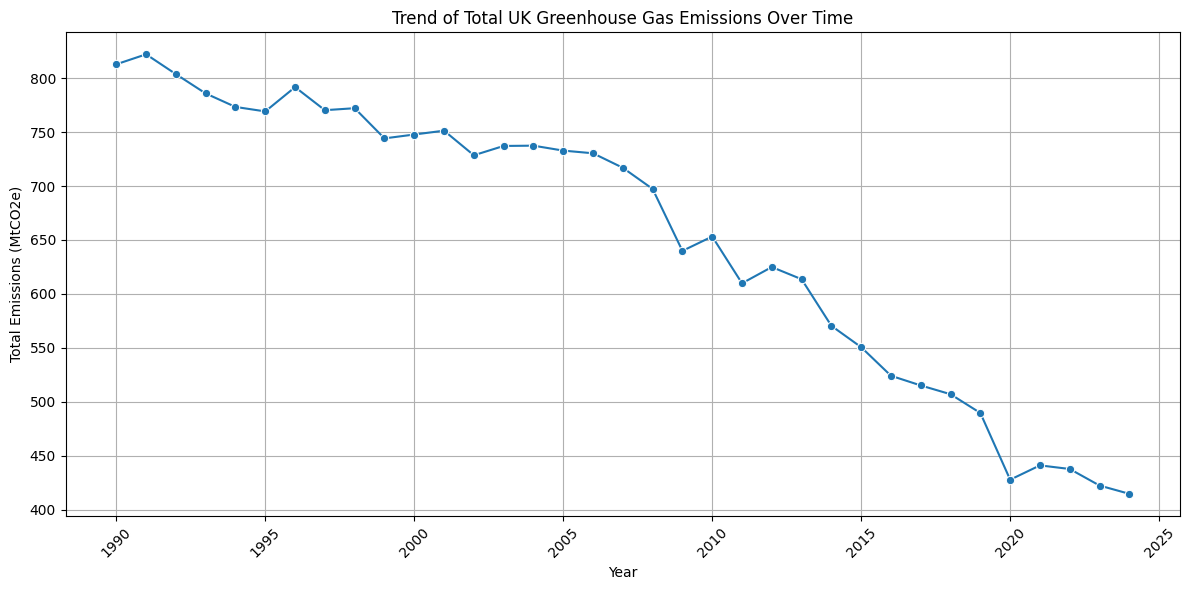

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Total_Emissions', data=yearly, marker='o')
plt.title('Trend of Total UK Greenhouse Gas Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total Emissions (MtCO2e)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

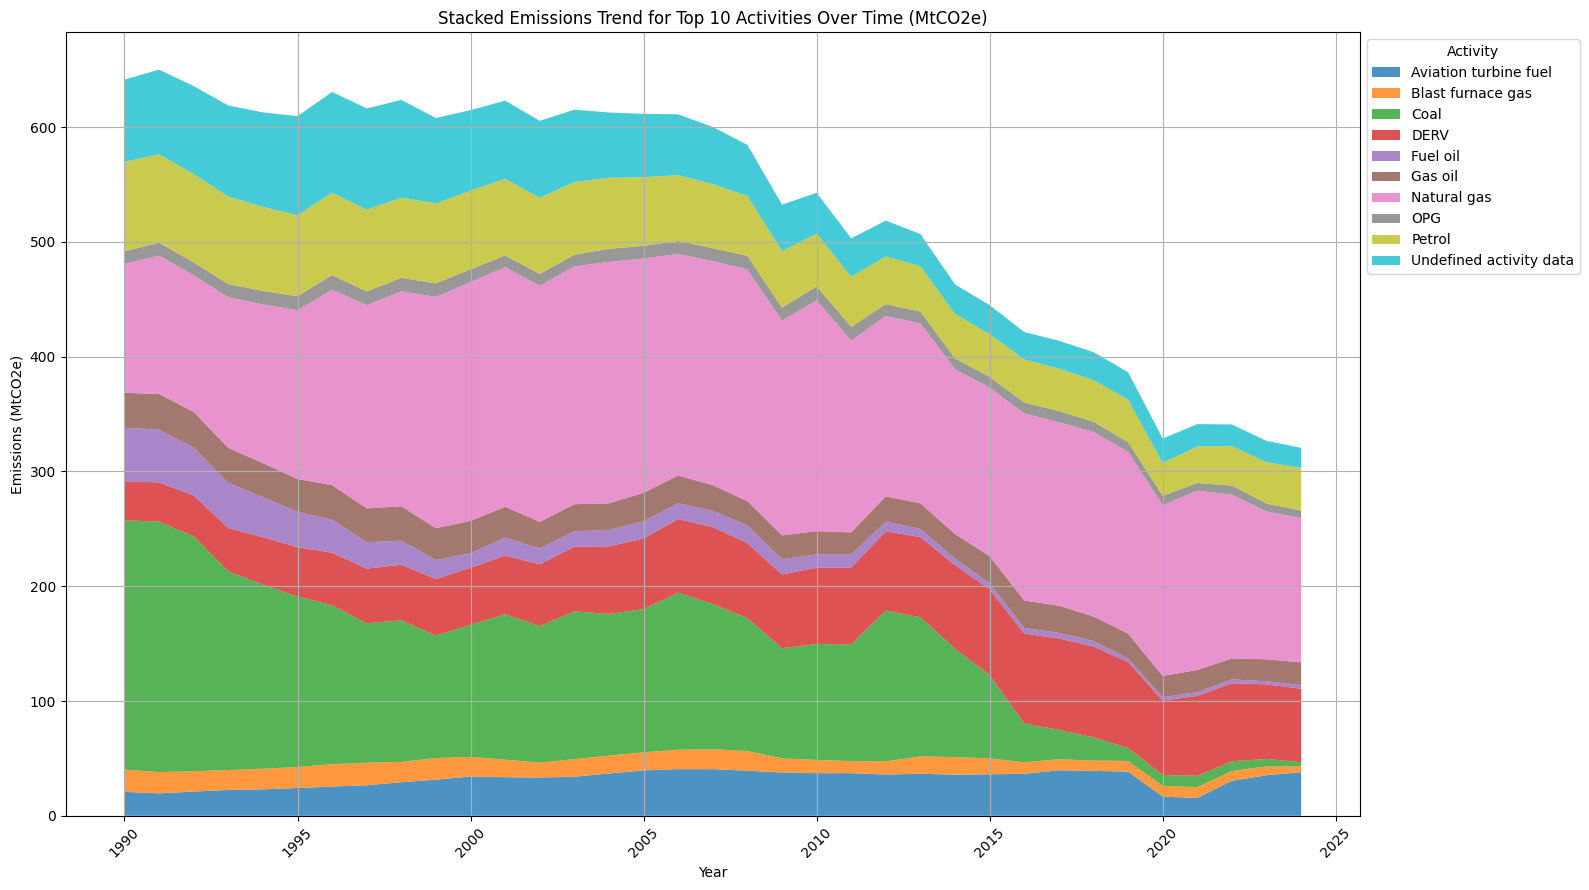

In [ ]:
total_emissions_by_activity = df_uk_by_source.groupby('Activity')['Emissions (MtCO2e)'].sum()
top_10_activities = total_emissions_by_activity.nlargest(10).index.tolist()
df_top_10_activities_yearly = df_uk_by_source[df_uk_by_source['Activity'].isin(top_10_activities)]
stacked_data = df_top_10_activities_yearly.groupby(['Year', 'Activity'])['Emissions (MtCO2e)'].sum().unstack(fill_value=0)

# Create the stacked line chart
plt.figure(figsize=(16, 9))
plt.stackplot(stacked_data.index, stacked_data.values.T, labels=stacked_data.columns, alpha=0.8)
plt.title('Stacked Emissions Trend for Top 10 Activities Over Time (MtCO2e)')
plt.xlabel('Year')
plt.ylabel('Emissions (MtCO2e)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Activity')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

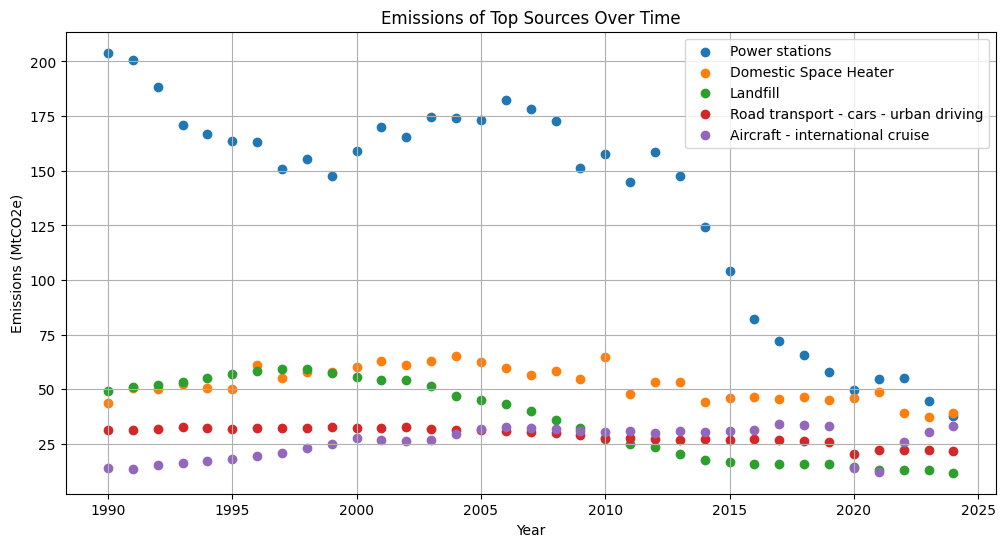

In [ ]:
top_sources = df_uk_by_source.groupby('Source')['Emissions (MtCO2e)'].sum().nlargest(5).index
df_top_sources_yearly = df_uk_by_source[df_uk_by_source['Source'].isin(top_sources)]
plt.figure(figsize=(12, 6))
for source in top_sources:
    yearly_source = df_top_sources_yearly[df_top_sources_yearly['Source'] == source].groupby('Year')['Emissions (MtCO2e)'].sum()
    plt.scatter(yearly_source.index, yearly_source.values, label=source)
plt.title('Emissions of Top Sources Over Time')
plt.xlabel('Year')
plt.ylabel('Emissions (MtCO2e)')
plt.legend()
plt.grid(True)
plt.show()

**Explanation**:

- **Total emissions have declined substantially over time**. Between 1990 and 2024, total emissions decreased from approximately 800 MtCO₂e to 400 MtCO₂e — representing a 50% reduction overall.
- **The distribution of emissions varies across activities and sources.** The largest contributors in terms of fuel-related activities are natural gas, DERV (diesel), and petrol, which account for a significant share of total emissions.
- **The contribution of specific activities has changed over time**. For example, between 1990 and 2015, coal represented one of the largest shares of total emissions. In recent years, however, coal usage has declined substantially and no longer constitutes a dominant source compared to other activities.
- **Several high-emitting activities stand out**, including power stations, domestic heating, road transport, and aviation. Notably, emissions from power stations have shown a steady decline since around 2012. This trend likely reflects the transition toward more sustainable energy sources, such as wind and solar power.




## **Question 2** Cluster Analysis

**2.1.** Choose one clustering algorithm discussed in the lectures and apply it to group emission sources or activities based on their emission trajectories over time.

In [ ]:
# Rows = activities, columns = years
activity_year = df_uk_by_source.groupby(["Year", "Activity"])["Emissions (MtCO2e)"].sum().unstack("Activity").fillna(0)
X_activities = activity_year.T
X_activities.shape

(221, 35)

In [ ]:
# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_activities)   # returns a numpy array
X_scaled_df = pd.DataFrame(X_scaled, index=X_activities.index, columns=X_activities.columns)

X_scaled_df.head()

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Activity,,,,,,,,,,,,,,,,,,,,,
Acid production,-0.013325,-0.012522,0.002741,0.009676,-0.056270,-0.063729,-0.064595,-0.067400,-0.042559,0.040271,...,-0.192811,-0.180225,-0.178790,-0.177156,-0.174234,-0.166501,-0.164802,-0.174505,-0.180518,-0.180413
Acrylonitrile,-0.199794,-0.198917,-0.202262,-0.210871,-0.211573,-0.212188,-0.209595,-0.207352,-0.202278,-0.194986,...,-0.194832,-0.181902,-0.181357,-0.178856,-0.176934,-0.170351,-0.167155,-0.176186,-0.182484,-0.181850
Active Aircraft,-0.199866,-0.198130,-0.200253,-0.208412,-0.209066,-0.209660,-0.207169,-0.204885,-0.199810,-0.192518,...,-0.193188,-0.179490,-0.178390,-0.177616,-0.174552,-0.168742,-0.165325,-0.174869,-0.182484,-0.181850
Adipic acid produced,0.763439,0.754461,0.562684,0.403148,0.482872,0.414254,0.384403,0.413636,0.392307,-0.165086,...,-0.194843,-0.181913,-0.181367,-0.178867,-0.176945,-0.170364,-0.167155,-0.176186,-0.182484,-0.181850
Agricultural Horses,-0.194202,-0.193208,-0.196142,-0.203326,-0.203540,-0.203675,-0.201058,-0.198805,-0.193953,-0.187397,...,-0.183446,-0.171313,-0.171000,-0.168819,-0.166595,-0.159641,-0.157160,-0.166106,-0.171949,-0.171605


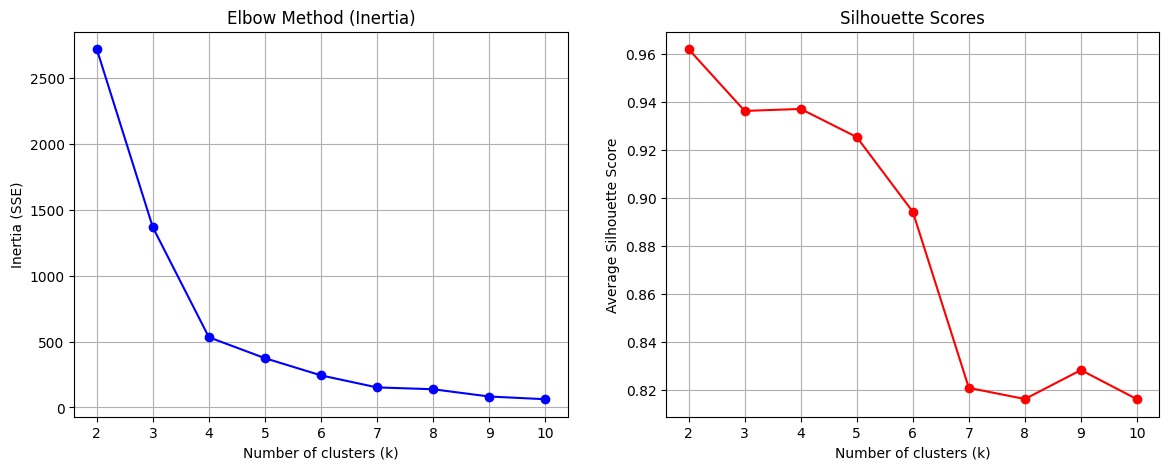

In [ ]:
# Finding k number for clustering
def plot_elbow_silhouette(X, k_min=2, k_max=10):
    inertias = []
    silhouettes = []
    ks = range(k_min, k_max+1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=1)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(ks, inertias, 'bo-')
    axes[0].set_title('Elbow Method (Inertia)')
    axes[0].set_xlabel('Number of clusters (k)')
    axes[0].set_ylabel('Inertia (SSE)')
    axes[0].grid(True)

    axes[1].plot(ks, silhouettes, 'ro-')
    axes[1].set_title('Silhouette Scores')
    axes[1].set_xlabel('Number of clusters (k)')
    axes[1].set_ylabel('Average Silhouette Score')
    axes[1].grid(True)
    plt.show()


plot_elbow_silhouette(X_scaled, k_min=2, k_max=10)

In [ ]:
# Clustering into 4 clusters
k_optimal = 4
km = KMeans(n_clusters=k_optimal, random_state=1)
labels = km.fit_predict(X_scaled)
X_activities['Cluster'] = labels

for cluster in range(k_optimal):
    print(f"\nCluster {cluster}:")
    print(X_activities[X_activities['Cluster'] == cluster].index.tolist())


Cluster 0:
['Acid production', 'Acrylonitrile', 'Active Aircraft', 'Adipic acid produced', 'Agricultural Horses', 'Ammonium Nitrate Application', 'Ammonium Nitrate Residue', 'Ammonium Sulphate and Diammonium Phosphate Application', 'Ammonium Sulphate and Diammonium Phosphate Residue', 'Animal Biomass', 'Anthracite', 'Aviation spirit', 'Barley residue', 'Bio-MTBE', 'Biodiesel', 'Biogas', 'Biogas in the gas grid', 'Biological waste', 'Blast furnace gas', 'Bricks', 'Burning oil', 'Calcium Ammonium Nitrate Application', 'Calcium Ammonium Nitrate Residue', 'Carbon black capacity', 'Charcoal', 'Charcoal produced', 'Clays & shales', 'Clinker production', 'Coal produced', 'Coffee Logs', 'Coke', 'Coke oven gas', 'Coke produced', 'Colliery methane', 'Cropland Converted to Other Wetlands', 'Cropland converted to Forest Land', 'Cropland converted to Grassland', 'Cropland converted to Settlements', 'Cropland remaining Cropland', 'Crude oil', 'Dairy - Dairy Cows', 'Deep mined coal production', 'Dee

**Interpretation for k = 4:**
- 3 major fossil fuels
    -   coal, natural gas, and the liquid transport fuels
    -   the emission time series is probably very different for these
-  +1:  everything else is sorted into one giant cluster
    - share enough similarity that emission patters are grouped

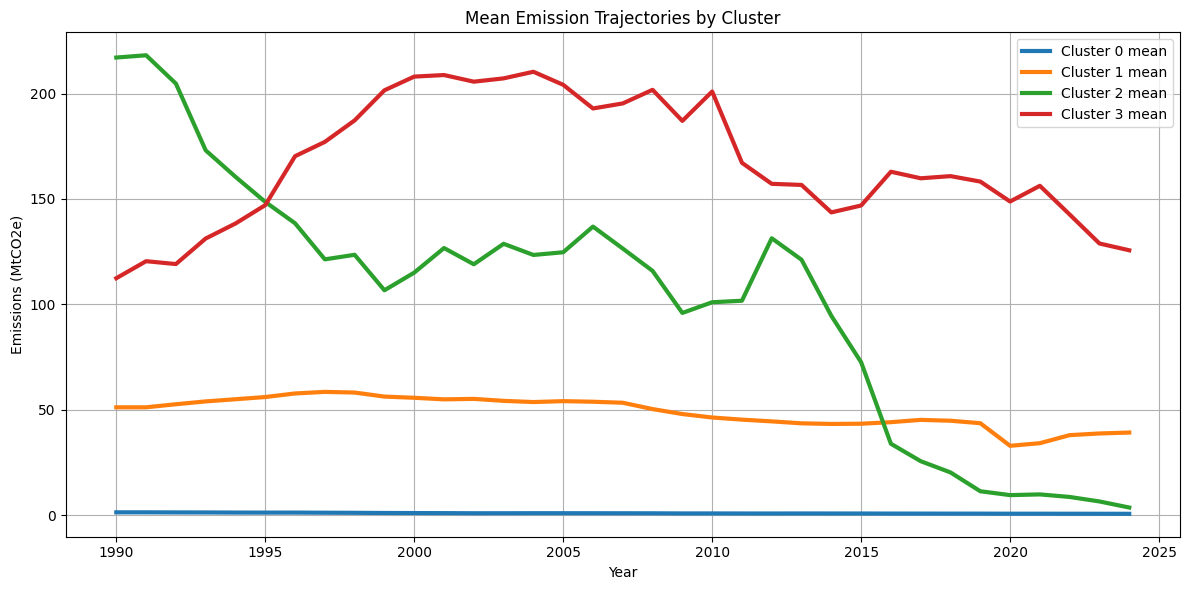

In [ ]:
# Plotting the clusters
plt.figure(figsize=(12,6))
years = activity_year.index

for cluster in range(4):
    cluster_activities = X_activities[X_activities['Cluster'] == cluster].index
    mean_traj = activity_year[cluster_activities].mean(axis=1)
    plt.plot(years, mean_traj, linewidth=3, label=f'Cluster {cluster} mean')

plt.xlabel('Year')
plt.ylabel('Emissions (MtCO2e)')
plt.title('Mean Emission Trajectories by Cluster')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**
- Cluster 0
    - activities with very low emissions and no visible pattern
    - no clear trend over time, flat
    - not key drivers of emission
- Cluster 1 - liquid fuels
    - moderate emissions, stable and flat pattern
    - small dip around 2020 - possibly due to COVID
    - demand is steady over the years
    - low correlation with year, moderate correlation with total emissions
- Cluster 2 - coal
    - steep decline over time - especially around 1990 and 2012
    - UK is phasing out coal
    - strong correlation with both year and total emission
    - key driver of the decreasing overall trend
- Cluster 3 - natural gas
    - increasing over time from 1990 to 2010 - replacing coal
    - after 2010 downward trend, but still the highest for emissions - possibly due to renewable sources
    - positive correlation is likely until 2010

**2.2.** Clearly justify the variables used for clustering (e.g., emission levels, rate of change, fuel group).
Interpret the resulting clusters and explain what they reveal about structural changes in UK
greenhouse gas emissions.

**Justification for variables used**

- We have chosen to cluster activities based on their emission patterns over time
- Activities can show a clearer pattern than Sources, since there are less unique and more grouped together
- We want to look at the structural changes in emissions over time - what increases or decreases, what is stable
- We use emission levels to cluster activities together
    - Goal is to see what is different between the active key drivers in national total emissions
- We cluster over the entire trajectory to see the paths that the activities take

**Structural Changes:**
- Cluster 0:
    - Since this group clusters together all activities that are not major drivers or emissions, they do not tell us much about structural changes. They are significant when put together, but indivisually their patterns are too flat, sporatic or low to measure

- Cluster 1:
    - Liquid fuels show a flat pattern. They are hard to decarbonise: the same time as vehicles become more efficient, the demand for travel also increases. This two effects balance each other out.
    - The small dip in 2020, most likely caused by COVID-19, shows that this cluster is vulnerable to short-term change, but rights itself rather fast

- Cluster 2:
    - Coal is the biggest driver in the UK's emissions recustion over time, being a key to structural change. Shows a clear trand of being phased-out and replaced by other fuels.

- Cluster 3:
    - Natural gas is what started to replace coal in order to decarbonise since 1990. Howewer, we see a decline in its usage, which suggest another trend for structural change, likely for renewable energy or an incline in improving energy efficiency.

**2.3.** Relate your clustering results to UK climate policy by identifying which clusters align with
sectors targeted under UK Carbon Budgets and which sectors appear more resistant to emission
reductions.

# **Clusters and their alignment to UK Policy**

Carbon budgets provide a legally binding upper limit on emissions for a five-year period *(Burnett, 2025)*.

**Cluster 2 - coal**
- Power sector - primary sector - *(Climate Change Committee, Sector summary – Electricity generation 2020)*
    - The steep decline aligns well with the 2013 Carbon Price Floor and the coal phase out commitment that the UK has made over the years.
    - Emissions from electricity generation fell by 62% between 2008 and 2018, reflecting a move away from coal towards gas and low-carbon generation.
- **Conclusion:** Cluster 2 reflects and is included in sectors that are highly responsive to regulation and carbon budgets.

**Cluster 3 - natural gas**
- Power sector
    - Gas replaced coal during the "dash for gas" in the 1990s *(Spooner, 1995)*.
    - 70% of emissions from electricity generation in 2019 came from burning natural gas *(Climate Change Committee, Sector summary – Electricity generation 2020)*.

- Heat & Buildings sector - *(Climate Change Committee, Sector summary – Buildings 2020)*
    - In 2019 around 74% of the UK’s heating and hot water demand in buildings was met by natural gas
    - UK plans to phase out natural gas used for heating by 2033
- **Conclusion:** Cluster 3 shows that while emissions are declining, natural gas remains one of the largest competitors, so sectors which include it will show a slower structural change.

**Cluster 1 - liquid fuels** ('Aviation turbine fuel', 'DERV', 'Petrol')
- Domestic Transport sector - *(Climate Change Committee, Sector summary – Aviation 2020)*
    - Largest emitting sector recently
    - Efficiency gains are offset by growing demand for travel
- International Aviation & Shipping sector - *(Climate Change Committee, Sector summary – Aviation 2020)*
    - Aviation turbine fuel is directly tied to this sector
    - Limited decarbonisation options: working on SAF, hydrogen aircraft
- **Conclusion:** Cluster 1 is short-term sensitive (which can be seen by the COVID-19 dip), but the sectors that incluse these liquid fuels are overall the most resistant to emission reductions.

**Most aligned with policy success:** Power sector (coal phase-out)

**Most resistant:** Transport and Aviation (liquid fuels - technological and infrastructure barriers)

## **Question 3** Policy Interpretation and Critical Analysis

**3.1.** Using the column Included in UK territorial total, compare emission trends with and
without international aviation and shipping. Discuss how this distinction affects progress assessment against UK Carbon Budgets.

In [ ]:
#check wether avation & shipping are exluded under the column "Included in UK territorial total"
df_uk_by_source[
    df_uk_by_source["Included in UK territorial total"] == "No"
][
    ["Included in UK territorial total",
     "Territorial Emissions Statistics category"]
].value_counts()

Included in UK territorial total  Territorial Emissions Statistics category
No                                International aviation                       1283
                                  International shipping                       1080
Name: count, dtype: int64

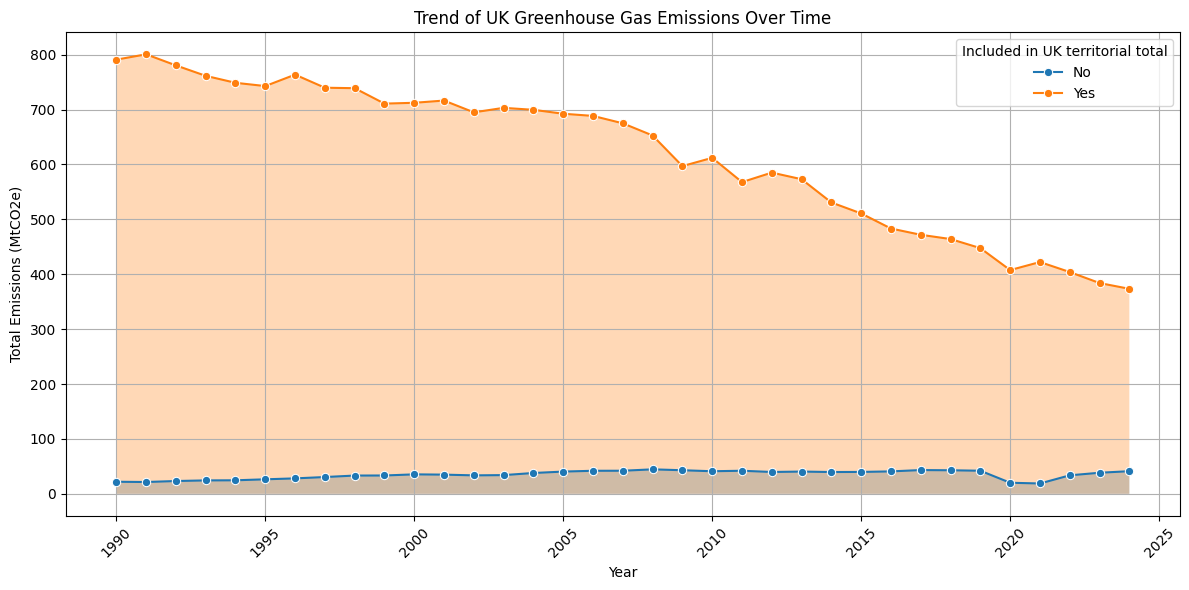

In [ ]:
yearly = df_uk_by_source.groupby(
    ['Year', 'Included in UK territorial total']
)['Emissions (MtCO2e)'].sum().reset_index()

plt.figure(figsize=(12, 6))

# Plot line
sns.lineplot(
    x='Year',
    y='Emissions (MtCO2e)',
    hue='Included in UK territorial total',
    data=yearly,
    marker='o'
)

# Area fill
for key, grp in yearly.groupby('Included in UK territorial total'):
    plt.fill_between(
        grp['Year'],
        grp['Emissions (MtCO2e)'],
        alpha=0.3
    )

plt.title('Trend of UK Greenhouse Gas Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total Emissions (MtCO2e)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
territorial_data = yearly[yearly["Included in UK territorial total"] == "Yes"]
aviation_data = yearly[yearly["Included in UK territorial total"] == "No"]

r_territorial = my_correlation(territorial_data["Year"].tolist(), territorial_data["Emissions (MtCO2e)"].tolist())
r_aviation = my_correlation(aviation_data["Year"].tolist(), aviation_data["Emissions (MtCO2e)"].tolist())

print(f"Territorial (Yes) correlation with year: r = {r_territorial:.3f}")
print(f"Aviation & Shipping (No) correlation:    r = {r_aviation:.3f}")

Territorial (Yes) correlation with year: r = -0.975
Aviation & Shipping (No) correlation:    r = 0.497


**INTERPRETATION**
- Emissions **included in the UK territorial** total show a clear and sustained downward trend over time.
  - From 1990 to recent years, total emissions have declined substantially from ~800 MtCO2e to ~380 MtCO2e (r = -0.975), reflecting successful reductions across major domestic sectors such as power generation, industry, and residential energy use.
  - **Note:** this r-value (-0.975) comes from the territorial-only subset. When we calculated it across all rows in Q1, it was slightly weaker at -0.9647, likely because including non-territorial emissions slightly softened the relationship.
  - This downward trajectory indicates steady progress toward meeting the UK's Carbon Budgets.
  - This downward trajectory indicates steady progress toward meeting the UK’s Carbon Budgets.

- Emissions **NOT included in UK territorial**: the trend is pretty much flat or slightly growing trend (r = +0.497).
  - Compared to 1990 and the recent years, aviation and shipping emissions are slightly higher today, indicating no structural decline.
  - A notable dip is observed around 2020, likely due to reduced air travel during Covid-19. However, emissions quickly recovered to pre-pandemic levels, suggesting no lasting structural change.

- **Progress assessment towards UK Carbon budgets**:
  - Declining domestic emissions may present an overly optimistic view of national progress.
  - While territorial emissions are decreasing, international transport and aviation emissions remain unchanged.
  - To have more realistic view, UK shouds consider these sectors when evaluating progress toward net-zero targets.

**3.2.** Using the “Included in UK Paris Agreement total” indicator, identify the emission sources that are covered under the UK’s reporting framework for the Paris Agreement. Discuss the implications of this coverage for interpreting the UK’s national emission reduction performance.

In [ ]:
# Filter rows included in Paris Agreement total
df_paris = df_unfccc_by_source[
    df_unfccc_by_source["Included in UK Paris Agreement total"] == "Yes"
]

covered_sources = df_paris["Source"].unique()
print("Sources covered under UK Paris Agreement reporting:")
print(covered_sources)

Sources covered under UK Paris Agreement reporting:
['Primary aluminium production - PFC emissions' 'Electronics and shoes'
 'Halocarbons production - fugitive' 'Firefighting' 'Power stations'
 'Heat supply' 'Refineries - combustion' 'Coke production'
 'Solid smokeless fuel production'
 'Upstream Gas Production - fuel combustion'
 'Gas terminal: fuel combustion'
 'Upstream Oil Production - fuel combustion'
 'Oil terminal: fuel combustion' 'Gas production'
 'Collieries - combustion' 'Nuclear fuel production'
 'Iron and steel - combustion plant' 'Non-Ferrous Metal (combustion)'
 'Chemicals (combustion)' 'Pulp, Paper and Print (combustion)'
 'Food & drink, tobacco (combustion)' 'Cement production - combustion'
 'Lime production - non decarbonising' 'Other industrial combustion'
 'NRMM: Mining and Quarrying' 'NRMM: Construction' 'NRMM: Generators'
 'NRMM: Other Industry' 'NRMM: Waste' 'Autogeneration - exported to grid'
 'Autogenerators' 'Aircraft between UK and Gibraltar - TOL'
 'Aircraft

In [ ]:
covered_categories = df_paris["Territorial Emissions Statistics category"].unique()
print("Categories covered under UK Paris Agreement reporting:")
print(covered_categories)

Categories covered under UK Paris Agreement reporting:
['Aluminium production - F-gases' 'Electronics and other - F-gases'
 'Halocarbon production - F-gases' 'Firefighting - F-gases'
 'Power stations - petroleum' 'Power stations - coal'
 'Power stations - gas' 'Power stations - municipal solid waste'
 'Power stations - other fuel' 'Other industrial combustion'
 'Oil refineries' 'Iron and steel - coke production'
 'Coal mining and handling' 'Gas platforms' 'Gas processing terminals'
 'Oil platforms' 'Oil processing terminals'
 'Gas distribution - combustion' 'Nuclear fuel production'
 'Iron and steel production' 'Industrial off-road mobile machinery'
 'Civil aviation' 'Passenger cars' 'Light duty vehicles' 'Buses' 'HGVs'
 'Mopeds & motorcycles' 'Road vehicle LPG and biofuel use (all vehicles)'
 'Railways - mobile combustion' 'Shipping - coastal' 'Shipping - other'
 'Aircraft support vehicles' 'Seaport machinery'
 'Refrigerated transport machinery' 'Commercial combustion'
 'Public sector

In [ ]:
# Filter rows NOT included in Paris Agreement total
df_paris_not_included = df_unfccc_by_source[
    df_unfccc_by_source["Included in UK Paris Agreement total"] == "No"
]

not_covered_sources = df_paris_not_included["Source"].unique()
print("Sources NOT covered under UK Paris Agreement reporting:")
print(not_covered_sources)

Sources NOT covered under UK Paris Agreement reporting:
['Firefighting' 'Power stations' 'Other industrial combustion'
 'Aircraft between UK and Bermuda - TOL'
 'Aircraft between UK and other OTs (excl Gib. and Bermuda) - TOL'
 'Aircraft - domestic take off and landing'
 'Road transport - cars - urban driving'
 'Road transport - LGVs - urban driving'
 'Road transport - buses and coaches - urban driving'
 'Road transport - HGV rigid - urban driving'
 'Road transport - HGV articulated - urban driving'
 'Road transport - mopeds (<50cc 2st) - urban driving'
 'Road transport - motorcycle (>50cc  2st) - urban driving'
 'Road transport - motorcycle (>50cc  4st) - urban driving'
 'Shipping between UK and Bermuda' 'Shipping - coastal'
 'Shipping between UK and Gibraltar'
 'Shipping between UK and OTs (excl. Gib and Bermuda)'
 'Miscellaneous industrial/commercial combustion' 'Domestic combustion'
 'Fishing vessels' 'Agriculture livestock - other cattle enteric'
 'Agriculture livestock - dairy ca

In [ ]:
# Filter rows NOT included in Paris Agreement total
not_covered_categories = df_paris_not_included["Territorial Emissions Statistics category"].unique()
print("categories NOT covered under UK Paris Agreement reporting:")
print(not_covered_categories)

categories NOT covered under UK Paris Agreement reporting:
['Firefighting - F-gases' 'Power stations - petroleum'
 'Other industrial combustion' 'Civil aviation' 'Passenger cars'
 'Light duty vehicles' 'Buses' 'HGVs' 'Mopeds & motorcycles'
 'Shipping - coastal' 'Commercial combustion' 'Residential combustion'
 'Fishing' 'Enteric fermentation - beef cattle'
 'Enteric fermentation - dairy cattle'
 'Enteric fermentation - other livestock' 'Enteric fermentation - pigs'
 'Enteric fermentation - sheep' 'Manure management - beef cattle'
 'Manure management - dairy cattle' 'Manure management - other livestock'
 'Manure management - pigs' 'Manure management - poultry'
 'Manure management - sheep' 'Landfill' 'Composting' 'Wastewater'
 'Incineration without energy recovery' 'Coal mining and handling'
 'Forest miscellaneous' 'Grassland miscellaneous' 'Domestic extraction'
 'Other product uses' 'Manufactured fertilisers'
 'Forest land remaining forest land' 'Cropland drained'
 'Settlement drained' 

**INTERPRETATION**

Checking what categories / sources are and are not included in Paris Agreement reveals that ***some detailed emission categories are excluded.*** Some of these categories (aggregated) are:

*   some international aviation & shipping;
*   granular agriculture livestock;
*   land-use carbon stock changes;
*   F-gas applications.


As a result, the reported UK emission reduction performance primarily reflects changes in core domestic sectors such as energy, transport, industry, and aggregated agriculture. While this ensures international comparability under UNFCCC guidelines, it may underrepresent the UK's broader climate impact, particularly in sectors experiencing growth such as international transport or in land-use carbon dynamics. Therefore, reductions reported under the Paris Agreement framework should be interpreted as reflecting performance within a defined reporting requirements rather than the entirety of emissions.

**3.3.** Based on your data-driven findings, critically assess whether historical emission trends suggest
that the UK is structurally aligned with its long-term climate targets. Support your answer with
quantitative evidence from your analysis.

In [ ]:
yearly_total = df_uk_by_source.groupby("Year")["Emissions (MtCO2e)"].sum().reset_index()
yearly_total.columns = ["Year", "Total_Emissions"]

first = yearly_total[yearly_total["Year"] == 1990]["Total_Emissions"].values[0] # 1990
last  = yearly_total["Total_Emissions"].iloc[-1] # 2024
pct_reduction = (first - last) / first * 100

print(f"1990 emissions:    {first:.1f} MtCO2e")
print(f"Latest emissions:  {last:.1f} MtCO2e")
print(f"Total reduction by 2024:   {pct_reduction:.1f}%")
print(f"UK target by 2030: 68% reduction from 1990 (UK Government, 2021)")
print(f"UK target by 2035: 78% reduction from 1990 (UK Government, 2021)")

1990 emissions:    812.8 MtCO2e
Latest emissions:  414.6 MtCO2e
Total reduction by 2024:   49.0%
UK target by 2030: 68% reduction from 1990 (UK Government, 2021)
UK target by 2035: 78% reduction from 1990 (UK Government, 2021)


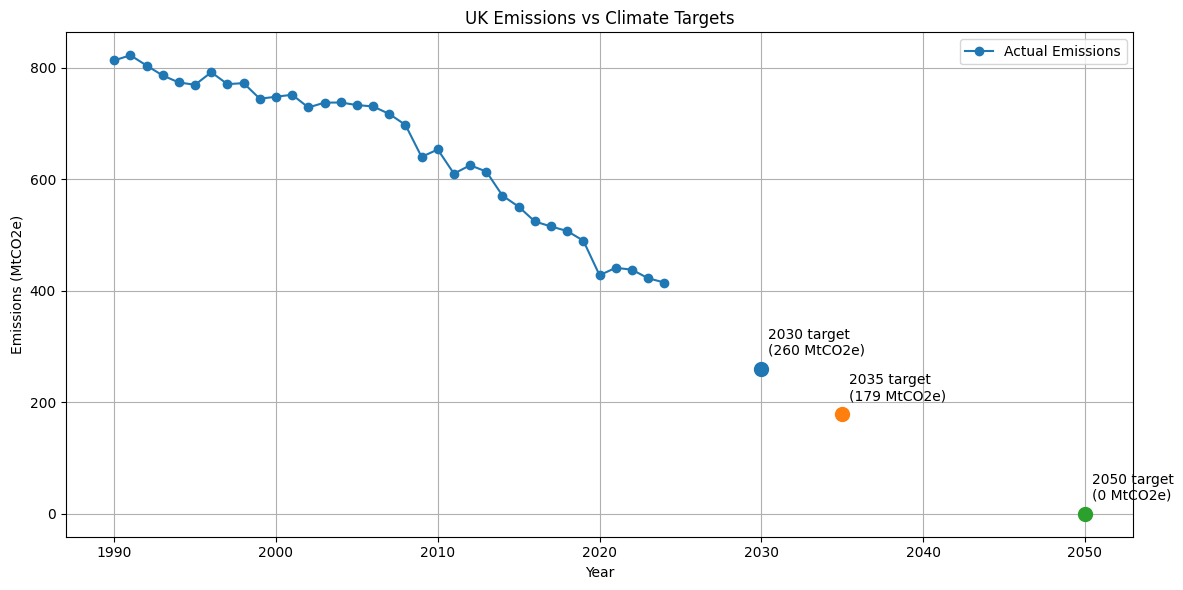

In [ ]:
# Target reductions from 1990 baseline
targets = {2030: 0.68, 2035: 0.78, 2050: 1.00}
target_values = {year: first * (1 - pct) for year, pct in targets.items()}

plt.figure(figsize=(12, 6))

# Actual emissions line
plt.plot(yearly_total["Year"], yearly_total["Total_Emissions"], marker='o', label="Actual Emissions")

# Scatter target points
for year, value in target_values.items():
    plt.scatter(year, value, s=100, zorder=5)
    plt.annotate(f"{year} target\n({value:.0f} MtCO2e)", xy=(year, value),
                 xytext=(5, 10), textcoords="offset points")

plt.title("UK Emissions vs Climate Targets")
plt.xlabel("Year")
plt.ylabel("Emissions (MtCO2e)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**INTERPRETATION**

The historical UK emissions data shows a reduction from 813 MtCO2e in 1990 to approximately 415 MtCO2e in 2024, which is roughly a 49% reduction (r = -0.965). This is a significant achievemnet, but looking at the targets on the chart, the UK still needs to reach 260 MtCO2e by 2030. That means cutting around 155 MtCO2e in just 6 years, which is more than what was cut in the entire period from 2010 to 2024.
What is also worth noting is that this progress has largely come from sectors that were easier to decarbonise, such as coal phase-out (Cluster 2) and energy efficiency improvements. The harder sectors are still a problem. Aviation and shipping show a positive correlation with year (r = +0.497), meaning they have actually grown over time, not declined. Liquid fuels (Cluster 1) show a flat pattern that barely responded even to Covid-19.
So while the overall trend looks positive, the sectors that have driven most of the decline so far are already close to zero emissions. The remaining reductions will need to come from sectors that have shown little to no change over the past 30 years. Based on the historical trend alone, the UK is not currently on pace to meet its upcoming targets.

## Reference list
- Burnett, N. (2025, February 4). What are carbon budgets?. UK Parliament. https://commonslibrary.parliament.uk/what-are-carbon-budgets/
- Carbon Budget Delivery Plan. (2023). Dandy Booksellers Ltd.
- Climate Change Committee. (2020). Sector summary – Aviation. https://www.theccc.org.uk/wp-content/uploads/2020/12/Sector-summary-Aviation.pdf
- Climate Change Committee. (2020). Sector summary – Buildings. https://www.theccc.org.uk/wp-content/uploads/2020/12/Sector-summary-Buildings.pdf
- Climate Change Committee. (2020). Sector summary – Electricity generation. https://www.theccc.org.uk/wp-content/uploads/2020/12/Sector-summary-Electricity-generation.pdf
- Spooner, D. (1995). The ‘Dash for Gas’ in Electricity Generation in the UK. Geography, 80(4), 393–406. https://doi.org/10.1080/20436564.1995.12452519
- UK Government. (2021). UK Enshrines New Target in Law to Slash Emissions by 78% by 2035. GOV.UK. https://www.gov.uk/government/news/uk-enshrines-new-target-in-law-to-slash-emissions-by-78-by-2035
